Descriptive Statistics
Obtain basic statistics for textual lengths (e.g., headline character count distribution)

Count articles per publisher to identify which sources are most active

Analyze publication dates to identify trends over time — are there spikes in news volume around specific market events?




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/raw_analyst_ratings.csv')
df=pd.DataFrame(data)
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [ ]:
df['headline_length'] = df['headline'].astype(str).apply(len)
display(df['headline_length'].describe())

,headline_length
count,76441.000000
mean,74.258042
std,41.106952
min,7.000000
25%,47.000000
50%,65.000000
75%,88.000000
max,458.000000


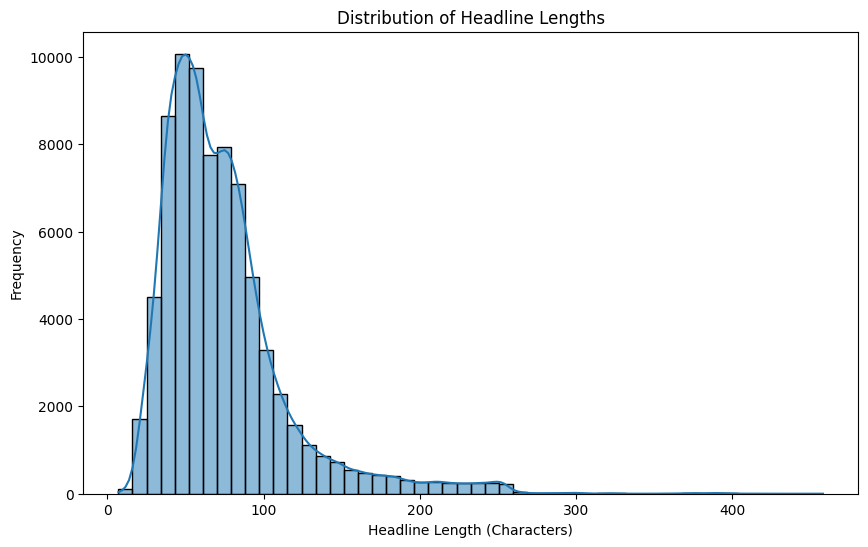

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length (Characters)')
plt.ylabel('Frequency')
plt.show()

The histogram displays the distribution of headline lengths in characters, showing the frequency of headlines within specific ranges. As observed, the graph is left-skewed, with the majority of headlines (approximately 12,000) falling within the 0-100 character length range.

In [ ]:
publisher_counts = df['publisher'].value_counts()
display(publisher_counts.head(10))

,count
publisher,
Paul Quintaro,12913
Lisa Levin,10722
Benzinga Newsdesk,8625
Charles Gross,4705
Monica Gerson,4584
Eddie Staley,3187
Hal Lindon,2922
Benzinga Staff,1915
Vick Meyer,1718


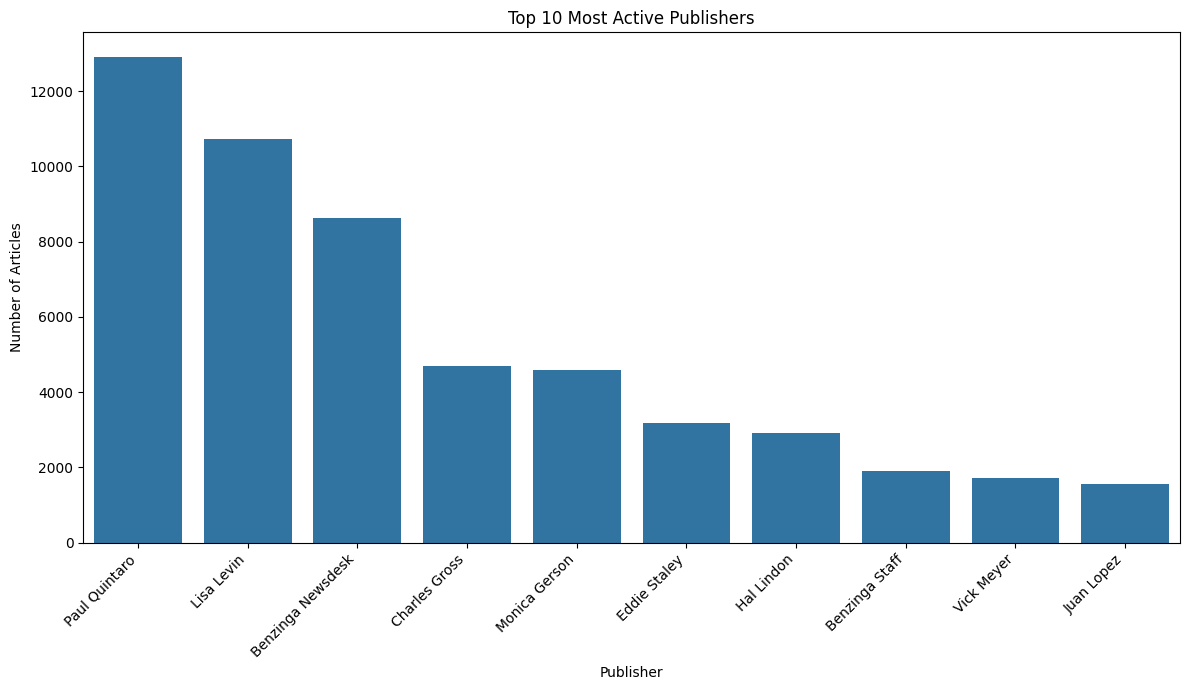

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=publisher_counts.head(10).index, y=publisher_counts.head(10).values)
plt.title('Top 10 Most Active Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This bar chart, titled 'Top 10 Most Active Publishers', visualizes the publishers with the highest number of articles in the dataset.

- The X-axis represents individual publishers.
- The Y-axis represents the total number of articles published by each publisher.

This visualization clearly shows which sources are most prolific, highlighting the significant contributions of publishers like Paul Quintaro to others and the visualization clearly shows that Paul Quintaro is the most active publisher and Juan Lopez is the least active publisher



In [ ]:
df['date'] = df['date'].astype(str)
df['date'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True, utc=True)
df.dropna(subset=['date'], inplace=True)
df['date'] = pd.Series(df['date'], dtype='datetime64[ns]') # Ensure the column is datetime type
df['publication_date'] = df['date'].dt.date
daily_article_counts = df['publication_date'].value_counts().sort_index()
display(daily_article_counts.head(30))

/tmp/ipykernel_5662/1261390059.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', infer_datetime_format=True, utc=True)


,count
publication_date,
2011-04-29,1
2011-05-02,1
2011-06-10,1
2011-07-18,1
2011-07-22,1
2011-07-25,1
2011-07-26,1
2011-07-27,2
2011-07-28,1


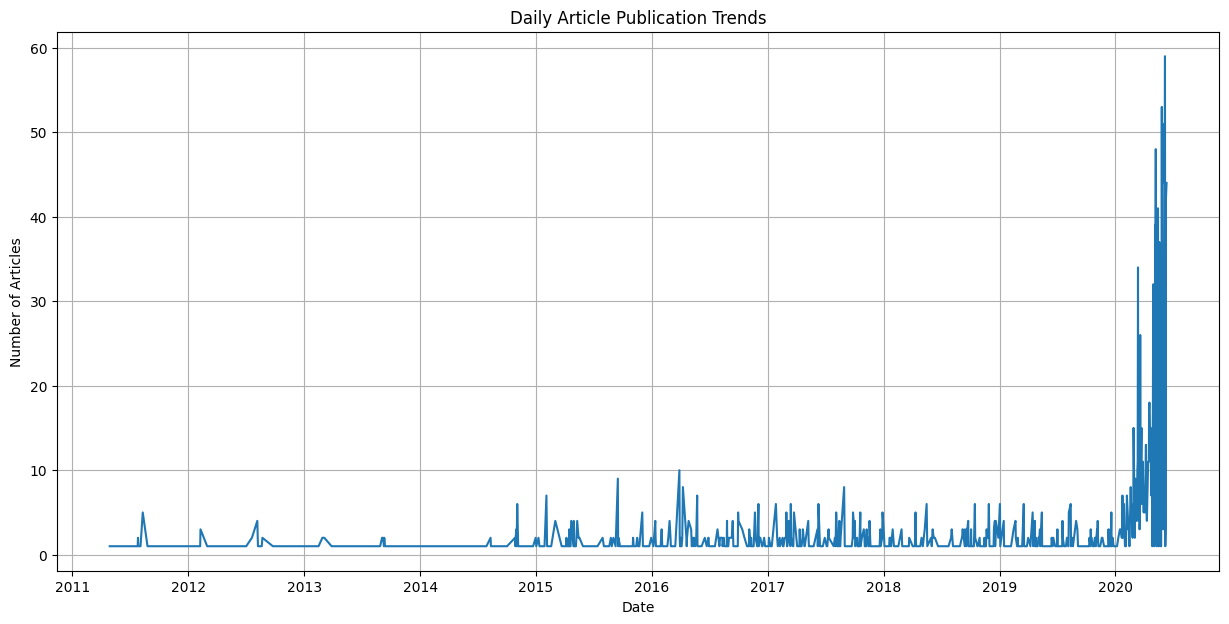

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(daily_article_counts.index, daily_article_counts.values)
plt.title('Daily Article Publication Trends')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

This line plot clearly shows the daily volume of article publications over time. A prominent trend appears to be a significant increase in publication activity over the years, with much higher article counts observed in later periods (e.g., in 2020) compared to the earlier years (e.g., 2011).

Within this broader trend, you can also see fluctuations in daily activity, with periods of lower publication (likely weekends or holidays) interspersed with noticeable spikes in news volume. These spikes could indeed correlate with specific market events or periods of high market volatility, as you initially hypothesized. The graph would allow us to pinpoint exact dates where such surges occurred, which might be valuable for further analysis.

In [ ]:
df['publication_month'] = df['date'].dt.to_period('M')
monthly_article_counts = df['publication_month'].value_counts().sort_index()
display(monthly_article_counts.head())

/tmp/ipykernel_5662/3564226525.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['publication_month'] = df['date'].dt.to_period('M')


,count
publication_month,
2011-04,1
2011-05,1
2011-06,1
2011-07,7
2011-08,9


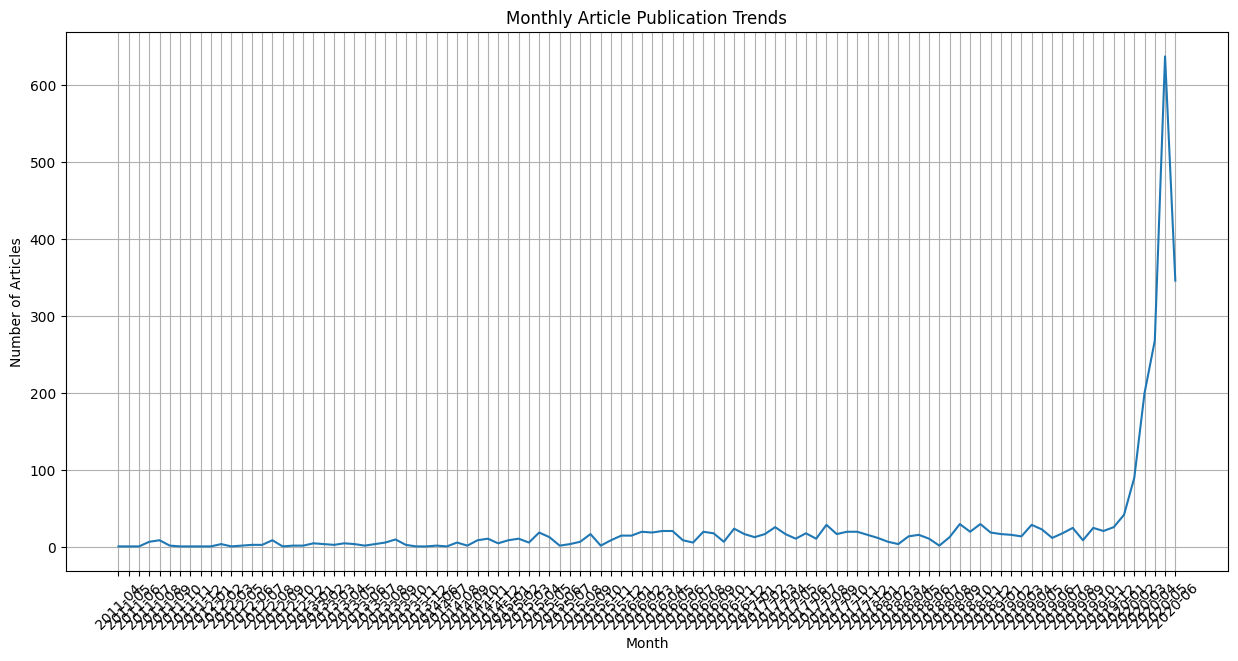

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(monthly_article_counts.index.astype(str), monthly_article_counts.values)
plt.title('Monthly Article Publication Trends')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()